In [97]:
import pandas as pd
import numpy as np
# read df from file
filename = 'FinFutYY.txt'

currencies_futures = {
    'AUD': {'ticker': '6A=F', 'name':'AUSTRALIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE'},
    'GBP': {'ticker': '6B=F', 'name':'BRITISH POUND STERLING - CHICAGO MERCANTILE EXCHANGE'},
    'CAD': {'ticker': '6C=F', 'name':'CANADIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE'},
    'EUR': {'ticker': '6E=F', 'name':'EURO FX - CHICAGO MERCANTILE EXCHANGE'},
    'JPY': {'ticker': '6J=F', 'name':'JAPANESE YEN - CHICAGO MERCANTILE EXCHANGE'},
    'NZD': {'ticker': '6N=F', 'name':'NEW ZEALAND DOLLAR - CHICAGO MERCANTILE EXCHANGE'},
    'CHF': {'ticker': '6S=F', 'name':'SWISS FRANC - CHICAGO MERCANTILE EXCHANGE'},
    'USD': {'ticker': 'DX=F', 'name':'U.S. DOLLAR INDEX - ICE FUTURES U.S.'},
}

asset = 'USD'
ticker = currencies_futures[asset]['ticker']
year = 2020

In [98]:
def drop_columns_with_patterns(df, patterns):
    """Drop columns that contain any of the specified patterns."""
    for col in df.columns:
        for pattern in patterns:
            if pattern in col and col in df.columns:
                df.drop(col, axis=1, inplace=True)
    return df

def rename_columns(df, rename_mapping):
    """Rename columns based on a list of dictionaries."""
    for mapping in rename_mapping:
        df.rename(columns=mapping, inplace=True)
    return df

def convert_datatypes(df):
    """Convert date column to datetime and numeric columns to float."""
    df['Date'] = pd.to_datetime(df['Date']).dt.date
    
    for col in df.columns:
        if col not in ['Market', 'Date']:
            df[col] = df[col].replace('.', np.nan)
            df[col] = df[col].astype(float)
    return df

# Read the data
df = pd.read_csv(filename)

contains = ['Conc_', 'Traders', 'Dealer', 'Other_Rept', 'NonRept', 'Pct_of_', 'CFTC_', 'As_of_Date_', 'Spread_', 
            'Contract_Units', 'FutOnly_or_Combined', 'Open_Interest_'] #, 'Positions_']

# Define columns to drop
df = drop_columns_with_patterns(df, contains)

names = [
    {'Market_and_Exchange_Names': 'Market'},
    {'Report_Date_as_YYYY-MM-DD': 'Date'},
    {'Asset_Mgr_Positions_Long_All': 'AM_L'},
    {'Asset_Mgr_Positions_Short_All': 'AM_S'},
    {'Lev_Money_Positions_Long_All': 'LM_L'},
    {'Lev_Money_Positions_Short_All': 'LM_S'},
    {'Tot_Rept_Positions_Long_All': 'TR_L'},
    {'Tot_Rept_Positions_Short_All': 'TR_S'},
    {'Change_in_Asset_Mgr_Long_All': 'Ch_AM_L'},
    {'Change_in_Asset_Mgr_Short_All': 'Ch_AM_S'},
    {'Change_in_Lev_Money_Long_All': 'Ch_LM_L'},
    {'Change_in_Lev_Money_Short_All': 'Ch_LM_S'},
    {'Change_in_Tot_Rept_Long_All': 'Ch_TR_L'},
    {'Change_in_Tot_Rept_Short_All': 'Ch_TR_S'},
]

# Rename columns
df = rename_columns(df, names)

# Convert datatypes
df = convert_datatypes(df)

# Rename the markets to the currency codes
for key, value in currencies_futures.items():
    df['Market'] = df['Market'].replace(value['name'], key)

# Keep only the rows with currency futures
df = df[df['Market'].isin(currencies_futures.keys())] 

df.head()


,Market,Date,AM_L,AM_S,LM_L,LM_S,TR_L,TR_S,Ch_AM_L,Ch_AM_S,Ch_LM_L,Ch_LM_S,Ch_TR_L,Ch_TR_S
0,CAD,2020-12-29,61555.0,18527.0,25676.0,24487.0,114387.0,140335.0,-2289.0,306.0,528.0,-6579.0,-992.0,-2298.0
1,CAD,2020-12-21,63844.0,18221.0,25148.0,31066.0,115379.0,142633.0,2299.0,607.0,2712.0,-23206.0,-35073.0,-38625.0
2,CAD,2020-12-15,61545.0,17614.0,22436.0,54272.0,150452.0,181258.0,-4057.0,-2455.0,1770.0,2121.0,32293.0,34622.0
3,CAD,2020-12-08,65602.0,20069.0,20666.0,52151.0,118159.0,146636.0,1994.0,95.0,5166.0,6679.0,11489.0,13785.0
4,CAD,2020-12-01,63608.0,19974.0,15500.0,45472.0,106670.0,132851.0,5241.0,922.0,-3256.0,2049.0,2965.0,7834.0


In [99]:
# create a copy of the dataframe for the asset
df_asset = df.loc[df['Market'] == asset].copy()

# sort by date
df_asset.sort_values(by='Date', inplace=True)

# use date as index
df_asset.set_index('Date', inplace=True)

# keep only Asset Manager data: columns 'AM_L', 'AM_S', 'Ch_AM_L', 'Ch_AM_S'
df_asset = df_asset[['AM_L', 'AM_S', 'Ch_AM_L', 'Ch_AM_S']]

# add a column 'AM_Net' that is the difference between 'AM_L' and 'AM_S'
df_asset['AM_Net'] = df_asset['AM_L'] - df_asset['AM_S']

df_asset.head()

,AM_L,AM_S,Ch_AM_L,Ch_AM_S,AM_Net
Date,,,,,
2020-01-07,5774.0,3465.0,-958.0,33.0,2309.0
2020-01-14,9105.0,3449.0,3331.0,-16.0,5656.0
2020-01-21,10320.0,3317.0,1215.0,-132.0,7003.0
2020-01-28,15432.0,2378.0,5112.0,-939.0,13054.0
2020-02-04,16395.0,1923.0,963.0,-455.0,14472.0


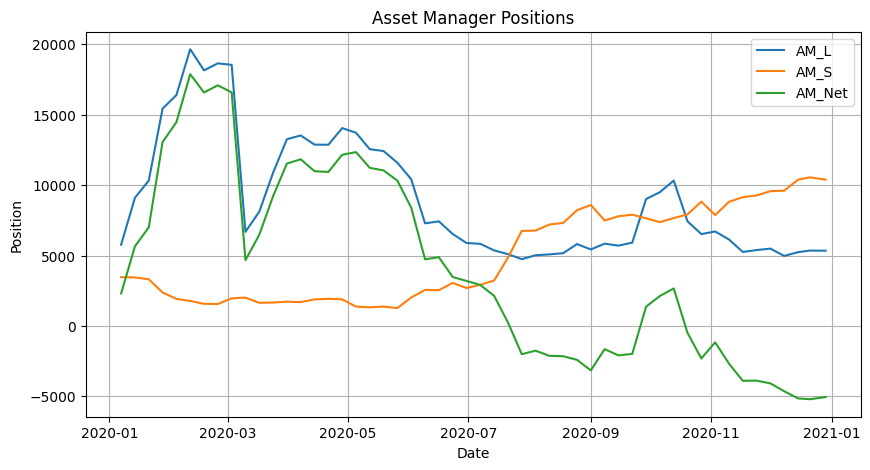

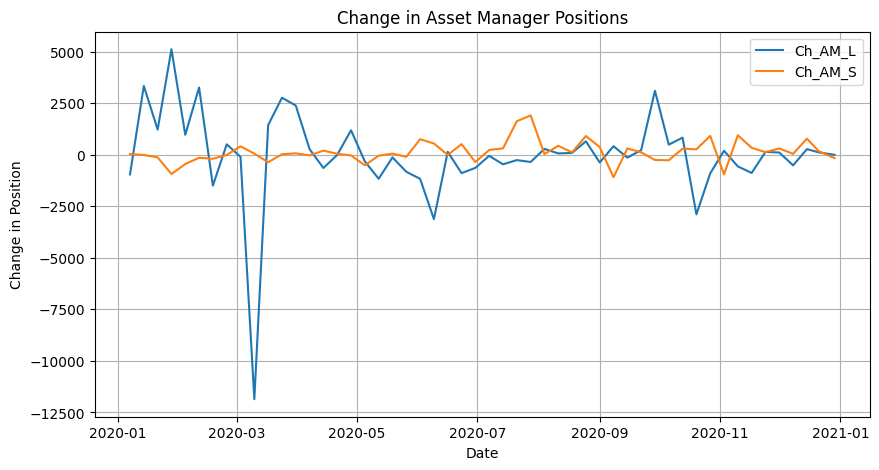

In [100]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(df_asset.index, df_asset['AM_L'], label='AM_L')
plt.plot(df_asset.index, df_asset['AM_S'], label='AM_S')
plt.plot(df_asset.index, df_asset['AM_Net'], label='AM_Net')
plt.title('Asset Manager Positions')
plt.xlabel('Date')
plt.ylabel('Position')
plt.legend()
plt.grid()
plt.show()

# in a separate plot, plot the changes in 'AM_L' and 'AM_S': Ch_AM_L and Ch_AM_S
plt.figure(figsize=(10, 5))
plt.plot(df_asset.index, df_asset['Ch_AM_L'], label='Ch_AM_L')
plt.plot(df_asset.index, df_asset['Ch_AM_S'], label='Ch_AM_S')
plt.title('Change in Asset Manager Positions')
plt.xlabel('Date')
plt.ylabel('Change in Position')
plt.legend()
plt.grid()
plt.show()



In [101]:
# get daily data from Yahoo Finance
import yfinance as yf

# check if the data has already been downloaded (the file exists)
import os
if os.path.exists(f'{asset}_{year}_daily_data.csv'):
    print(f'The file {asset}_{year}_daily_data.csv already exists.')
else:
    # get the data
    data = yf.download(ticker, start=f'{year}-01-01', end=f'{year}-12-31')
    # save the data to a file
    data.to_csv(f'{asset}_{year}_daily_data.csv')
    print(f'The file {asset}_{year}_daily_data.csv has been created.')


The file USD_2020_daily_data.csv already exists.


In [102]:
# read the data from the file
price_data = f'{asset}_{year}_daily_data.csv'
data = pd.read_csv(price_data)
# drop the first 2 rows
data = data.iloc[2:]
# reset the index
data = data.reset_index(drop=True)
# rename Price to Date
data.rename(columns={'Price': 'Date'}, inplace=True)
# keep only the columns Date and Close
data = data[['Date', 'Close']]
# use Date as index
data.set_index('Date', inplace=True)
# Close as float
data['Close'] = data['Close'].astype(float)

# First ensure the index of both dataframes is a datetime index
df_asset.index = pd.to_datetime(df_asset.index)
data.index = pd.to_datetime(data.index)

# print the first 5 rows
data.head()



,Close
Date,
2020-01-02,96.525002
2020-01-03,96.521004
2020-01-06,96.349998
2020-01-07,96.702003
2020-01-08,96.996002


In [103]:
# print types of the columns for the 2 dataframes
print(df_asset.dtypes)
print(data.dtypes)
# type of index
print(df_asset.index.dtype)
print(data.index.dtype)

AM_L       float64
AM_S       float64
Ch_AM_L    float64
Ch_AM_S    float64
AM_Net     float64
dtype: object
Close    float64
dtype: object
datetime64[ns]
datetime64[ns]


In [104]:
# drop all except AM_net from df_asset
df_asset.drop(columns=['AM_L', 'AM_S', 'Ch_AM_L', 'Ch_AM_S'], inplace=True)
df_asset.head()

,AM_Net
Date,
2020-01-07,2309.0
2020-01-14,5656.0
2020-01-21,7003.0
2020-01-28,13054.0
2020-02-04,14472.0


In [105]:
data.head()

,Close
Date,
2020-01-02,96.525002
2020-01-03,96.521004
2020-01-06,96.349998
2020-01-07,96.702003
2020-01-08,96.996002


In [ ]:
# add df_asset to data dataframe, forwards fill the NaN values
data = data.join(df_asset, how='left')
# data.fillna(method='ffill', inplace=True)
data.ffill(inplace=True)
# drop rows with NaN values
data.dropna(inplace=True)

In [109]:
data.head()

,Close,AM_Net
Date,,
2020-01-07,96.702003,2309.0
2020-01-08,96.996002,2309.0
2020-01-09,97.162003,2309.0
2020-01-10,97.078003,2309.0
2020-01-13,97.059998,2309.0


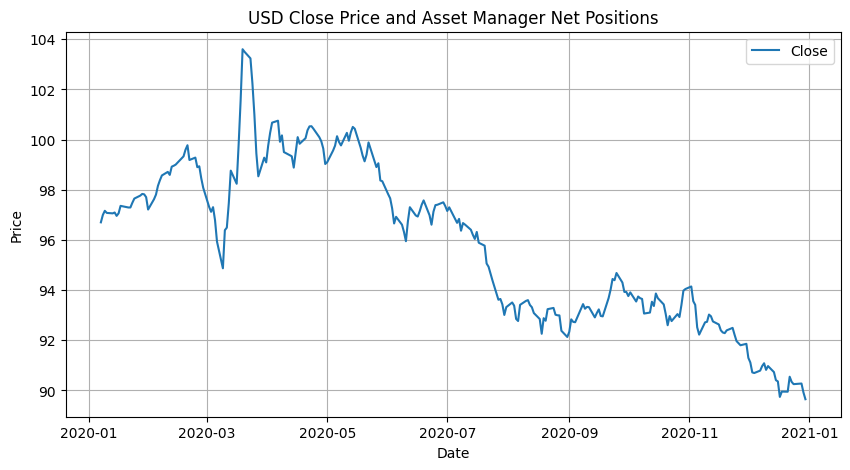

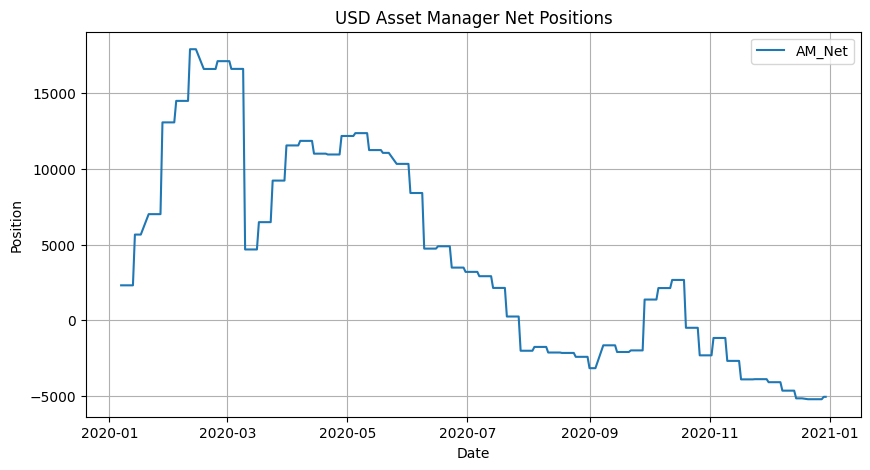

In [ ]:
# plot the data
plt.figure(figsize=(10, 5))
plt.plot(data.index, data['Close'], label='Close')
plt.title(f'{asset} Close Price and Asset Manager Net Positions')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()
# plot asset manager net positions
plt.figure(figsize=(10, 5))
plt.plot(data.index, data['AM_Net'], label='AM_Net')
plt.title(f'{asset} Asset Manager Net Positions')
plt.xlabel('Date')
plt.ylabel('Position')
plt.legend()
plt.grid()
plt.show()


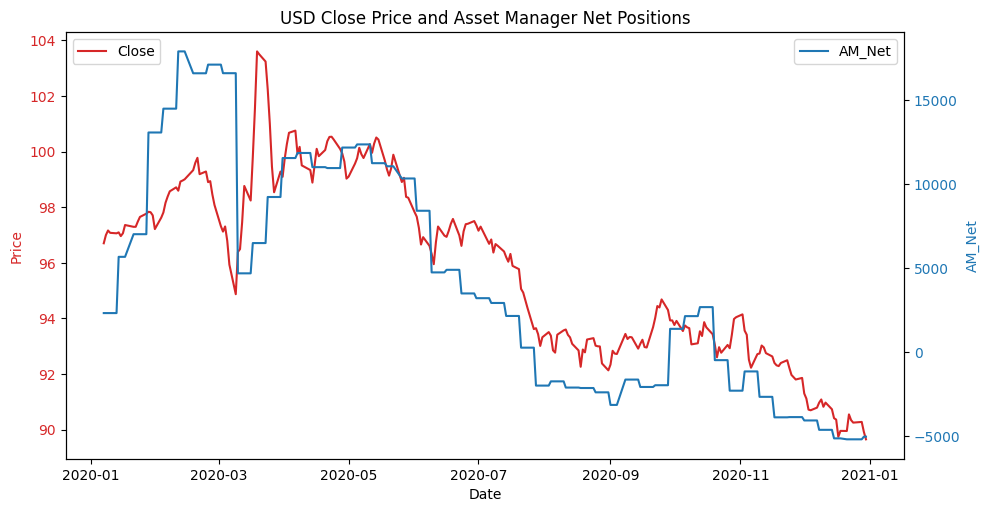

In [111]:
# plot both on the same plot with 2 y-axes
fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'tab:red'
ax1.set_xlabel('Date')
ax1.set_ylabel('Price', color=color)
ax1.plot(data.index, data['Close'], color=color, label='Close')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:blue'
ax2.set_ylabel('AM_Net', color=color)  # we already handled the x-label with ax1
ax2.plot(data.index, data['AM_Net'], color=color, label='AM_Net')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title(f'{asset} Close Price and Asset Manager Net Positions')
plt.show()

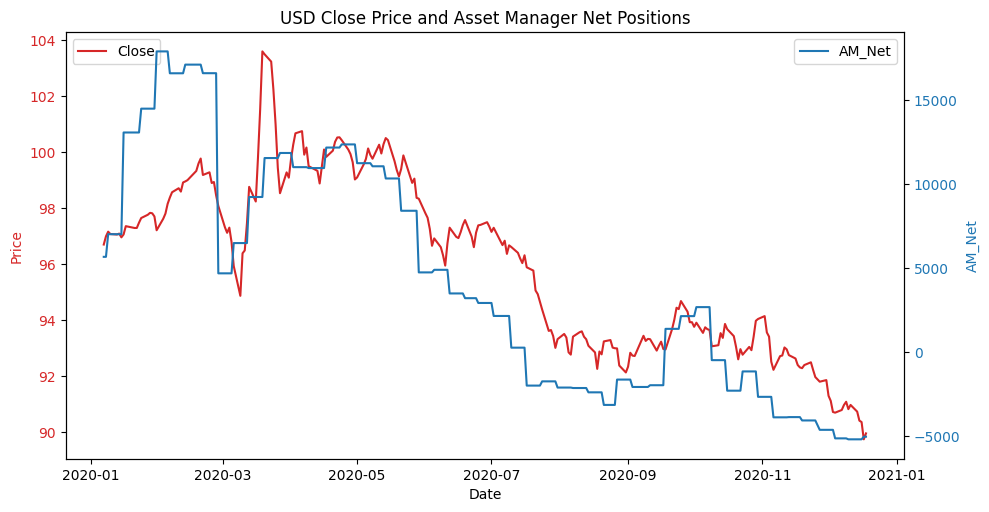

In [113]:
# since the COT is delayed by a week days, we will plot the AM_Net back by 7 days using another df
data_shifted = data.copy()
# shift the AM_Net column by 7 days
data_shifted['AM_Net'] = data_shifted['AM_Net'].shift(-7)
# drop rows with NaN values
data_shifted.dropna(inplace=True)

# plot both on the same plot with 2 y-axes
fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'tab:red'
ax1.set_xlabel('Date')
ax1.set_ylabel('Price', color=color)
ax1.plot(data_shifted.index, data_shifted['Close'], color=color, label='Close')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:blue'
ax2.set_ylabel('AM_Net', color=color)  # we already handled the x-label with ax1
ax2.plot(data_shifted.index, data_shifted['AM_Net'], color=color, label='AM_Net')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title(f'{asset} Close Price and Asset Manager Net Positions')
plt.show()
